<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

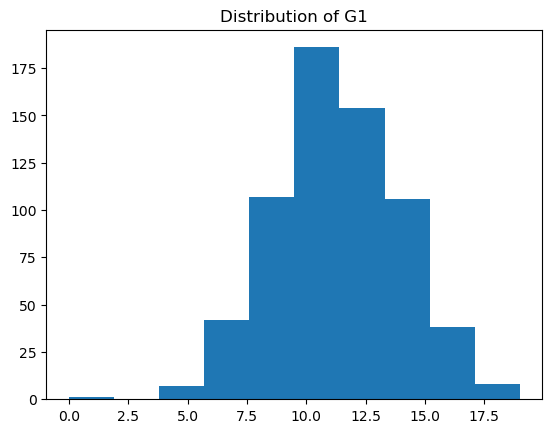

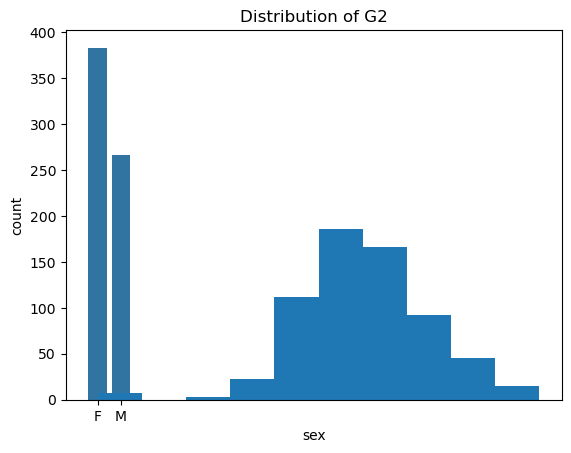

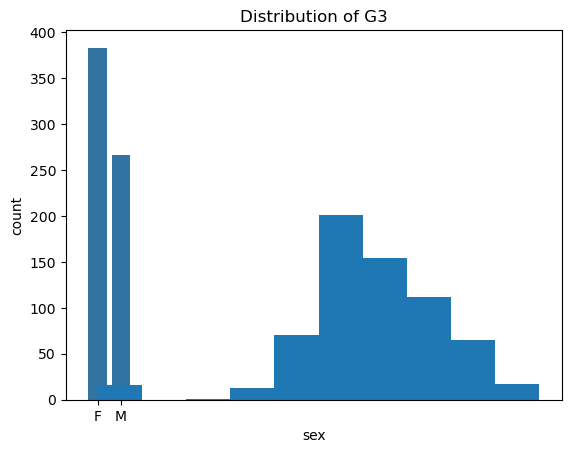

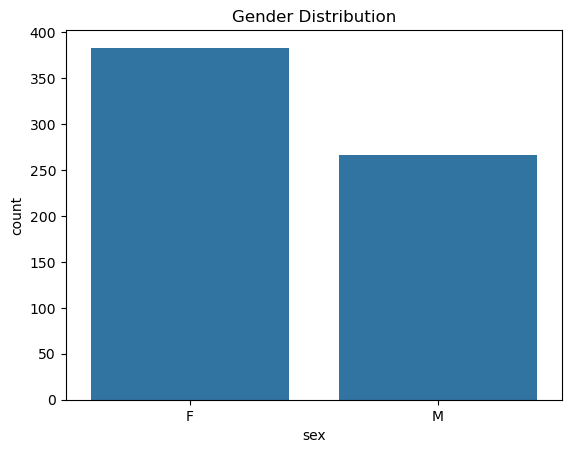

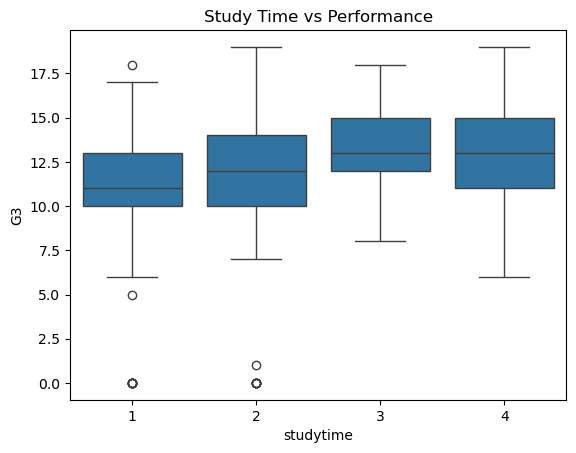

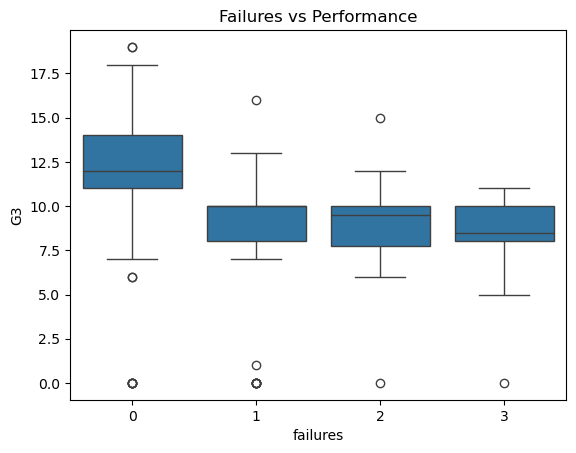

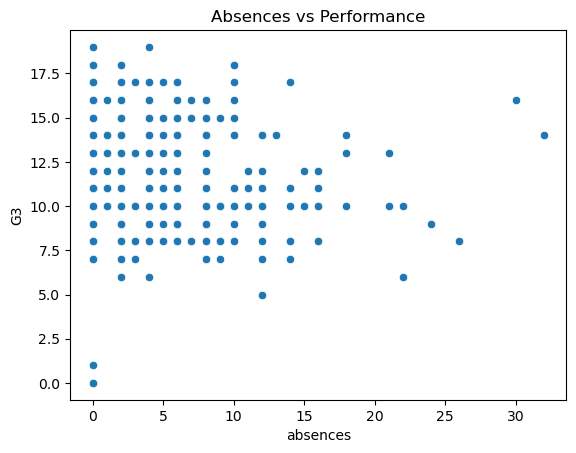

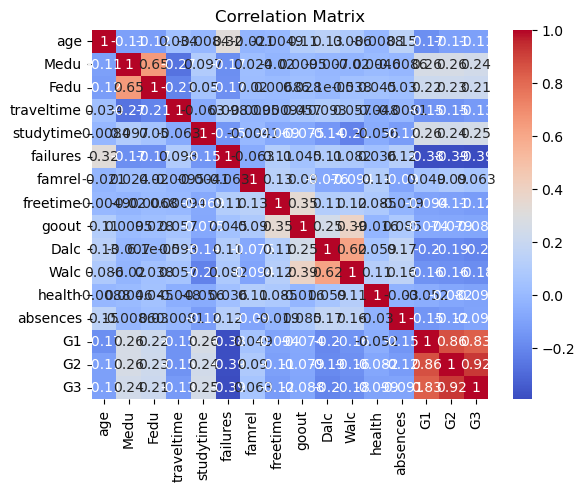

Decision Tree MSE: 3.295668240041581
Decision Tree R2: 0.7463022990949134
Random Forest MSE: 3.431940769230769
Random Forest R2: 0.7358121572378611


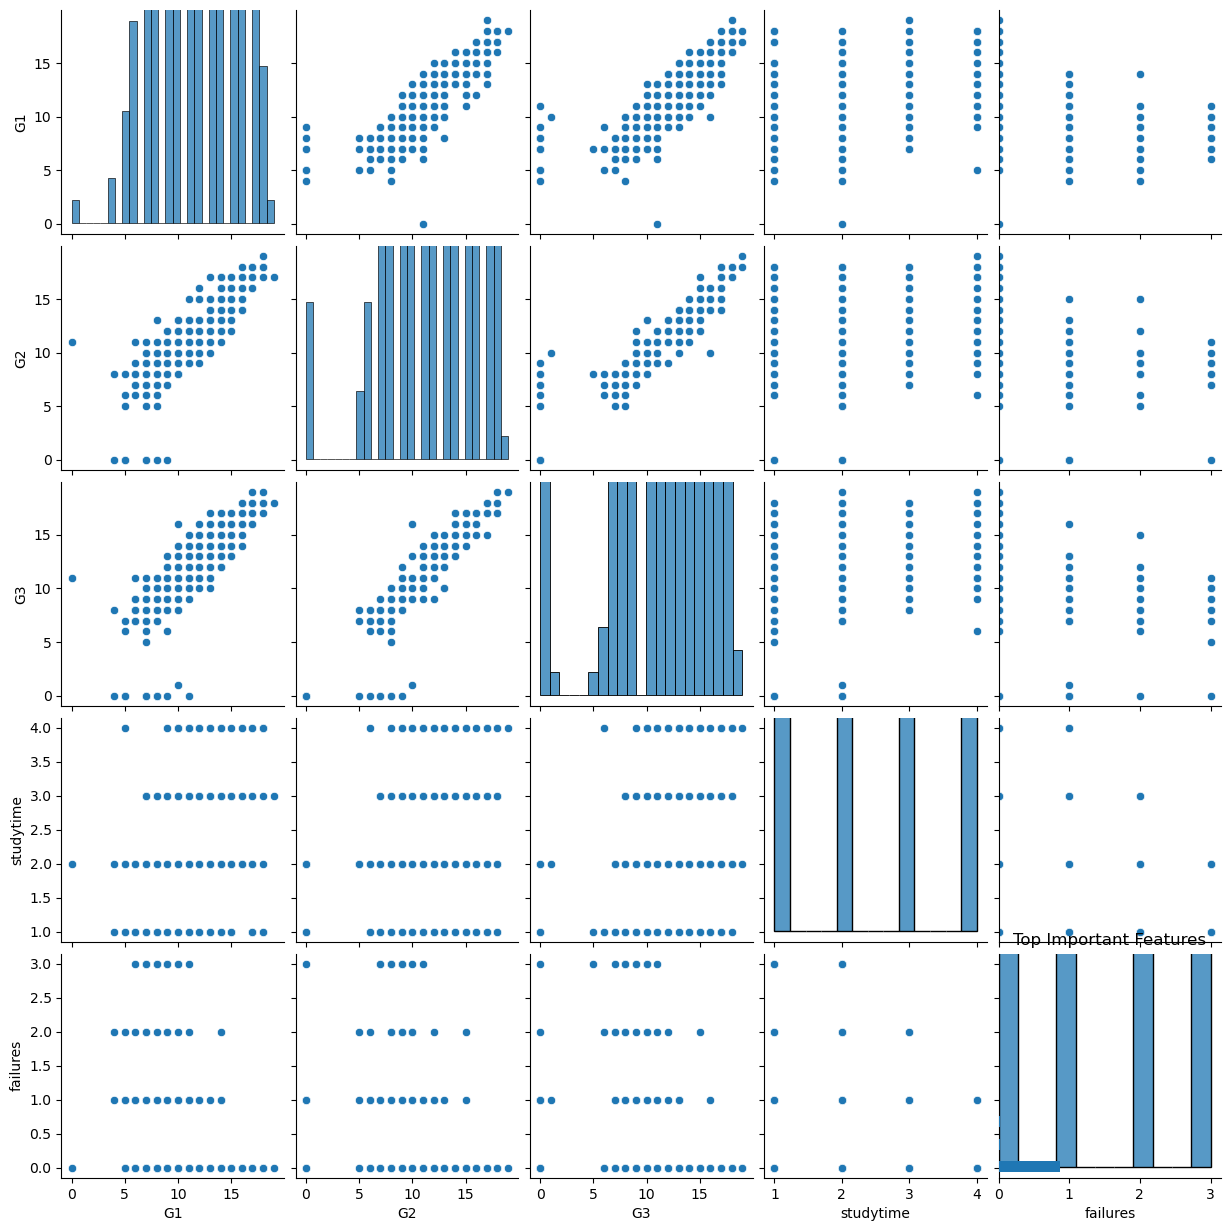

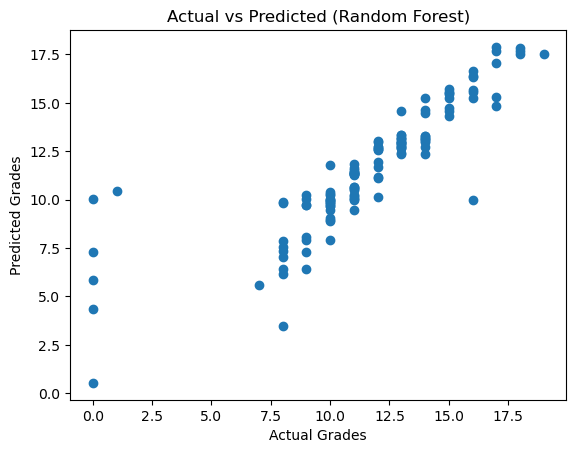

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv(r"C:\Users\poona\student-por.csv")
#print(data.columns)
data.head()
data.info()
data.describe()
data.isnull().sum()
data = data.drop_duplicates()
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

print("Numerical:", num_cols)
print("Categorical:", cat_cols)
for col in ['G1','G2','G3']:
    plt.hist(data[col], bins=10)
    plt.title(f"Distribution of {col}")
    plt.show()
    sns.countplot(x='sex', data=data)
plt.title("Gender Distribution")
plt.show()
sns.boxplot(x='studytime', y='G3', data=data)
plt.title("Study Time vs Performance")
plt.show()
sns.boxplot(x='failures', y='G3', data=data)
plt.title("Failures vs Performance")
plt.show()
sns.scatterplot(x='absences', y='G3', data=data)
plt.title("Absences vs Performance")
plt.show()
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
sns.pairplot(data[['G1','G2','G3','studytime','failures']])
data.groupby('studytime')['G3'].mean()
data.groupby('failures')['G3'].mean()
data.groupby('sex')['G3'].mean()
# Top performers
top_students = data[data['G3'] > 15]

# Low performers
low_students = data[data['G3'] < 5]
# Convert categorical to numerical
data_encoded = pd.get_dummies(data, drop_first=True)
X = data_encoded.drop('G3', axis=1)
y = data_encoded['G3']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(max_depth=5)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score

print("Decision Tree MSE:", mean_squared_error(y_test, y_pred_dt))
print("Decision Tree R2:", r2_score(y_test, y_pred_dt))
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top Important Features")
plt.show()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()


Study time positively influences student performance

Failures and absences negatively impact academic outcomes

Early grades (G1, G2) are the strongest predictors

Random Forest performed better than Decision Tree

Machine learning models can help identify at-risk students early